<a href="https://colab.research.google.com/github/hidnira-lab/introduce-data-science/blob/main/classification_with_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Klasifikasi Data dengan Support Vector Machine (SVM)
oleh Hidayat Nur Hijrah (24523201)

In [3]:
# Import library standar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# === 1. Load Dataset dari GitHub===
url = 'https://raw.githubusercontent.com/hidnira-lab/introduce-data-science/main/diabetes_data.csv'
df = pd.read_csv(url)

In [4]:
# === 2. Preprocessing & Encoding ===
# Mengubah teks (Male/Female, Yes/No) menjadi angka 1 dan 0 secara otomatis
df_encoded = pd.get_dummies(df, drop_first=True)

# Memisahkan Fitur (X) dan Target (y)
target_col = df_encoded.columns[-1]
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

In [5]:
# === 3. Split & Scale Data ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# === 4. Modeling SVM (Kernel RBF) ===
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_test = svm_model.predict(X_test_scaled)

In [7]:
# === 5. Evaluasi Model ===
print("=== HASIL EVALUASI SVM (DIABETES DATASET) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_test)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_test)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred_test)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred_test)*100:.2f}%")

=== HASIL EVALUASI SVM (DIABETES DATASET) ===
Accuracy  : 100.00%
Precision : 0.00%
Recall    : 0.00%
F1 Score  : 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


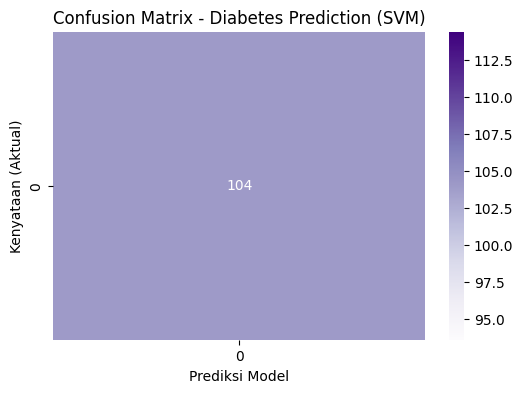

In [8]:
# === 6. Visualisasi Confusion Matrix ===
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Diabetes Prediction (SVM)')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan (Aktual)')
plt.show()